In [ ]:

import numpy as np
from scipy import ndimage, spatial


def extract_outer_surface(mesh):
    # check if mesh is touched by the boundary of the volume
    if (np.any([mesh[i, :, :].any() for i in [0, -1]])
        or np.any([mesh[:, i, :].any() for i in [0, -1]])
        or np.any([mesh[:, :, i].any() for i in [0, -1]])):
        raise ValueError("Mesh touches the boundary of the volume. "
                         "Cannot dilate mesh to create outer surface.")

    dialated_mesh = ndimage.binary_dilation(mesh > 0)
    outer_mesh = dialated_mesh & (mesh == 0)
    return outer_mesh


def label_endo_epi_surface(outer_mesh, axis=2):
    surface_mesh = outer_mesh.copy()
    axis_max = np.argwhere(outer_mesh > 0).max(axis=0)[axis]

    idx = [slice(None)] * outer_mesh.ndim
    idx[axis] = axis_max
    surface_mesh[tuple(idx)] = 0

    surface_labeled, n_surfaces = ndimage.label(surface_mesh > 0, structure=np.ones((3, 3, 3)))
    if n_surfaces != 2:
        raise ValueError(f"Expected 2 surfaces, but found {n_surfaces}.")

    return surface_labeled


def select_points_within_distance(source_points, target_points, distance):
    tree = spatial.KDTree(target_points)
    closest_indices = tree.query_ball_point(np.atleast_2d(source_points), distance)
    closest_indices = np.concatenate(closest_indices)
    return closest_indices 


def apex_base_regions(outer_mesh, axis=2, apex_size=5, apex_point=None):
    coords = np.argwhere(outer_mesh > 0)
    coord_max = coords.max(axis=0)

    surface_mesh = np.zeros_like(outer_mesh, dtype=np.uint8)
    idx = [slice(None)] * outer_mesh.ndim
    idx[axis] = coord_max[axis]
    surface_mesh[tuple(idx)] = 1

    if apex_point is None:
        coord_min = coords.min(axis=0)
        apex_point = coords[coords[:, axis] == coord_min[axis]].mean(axis=0)

    apex_indices = select_points_within_distance(apex_point, coords, apex_size)
    surface_mesh[tuple(coords[apex_indices].T)] = 2
    return surface_mesh


def make_boundaries(indices, outer_mesh, label_func, label_values=[1, -1], axis=2, **label_func_kwargs):
    labeled_mesh = label_func(outer_mesh, axis=axis, **label_func_kwargs)
    local_indices = np.arange(indices.size)

    boundaries = []
    for i, val in enumerate(label_values):
        label_indices = local_indices[labeled_mesh.flat[indices] == i + 1]
        boundaries.append((label_indices, val))

    return boundaries



In [59]:
from pathlib import Path
import matplotlib.pyplot as plt


path = Path("./data")

sim_mesh = np.load(path / "lv_mesh.npy")
apex_center = np.array([102, 35, 15], dtype=np.int64)

outer_mesh = extract_outer_surface(sim_mesh)
full_mesh = sim_mesh + outer_mesh
full_coords = np.argwhere(full_mesh > 0)
full_indices = np.flatnonzero(full_mesh > 0)

endo_epi_boundaries = make_boundaries(full_indices, outer_mesh, label_endo_epi_surface)
apex_base_boundaries = make_boundaries(full_indices, outer_mesh, apex_base_regions, apex_point=apex_center, apex_size=5)

epi_coords = full_coords[endo_epi_boundaries[0][0]]
endo_coords = full_coords[endo_epi_boundaries[1][0]]
base_coords = full_coords[apex_base_boundaries[0][0]]
apex_coords = full_coords[apex_base_boundaries[1][0]]

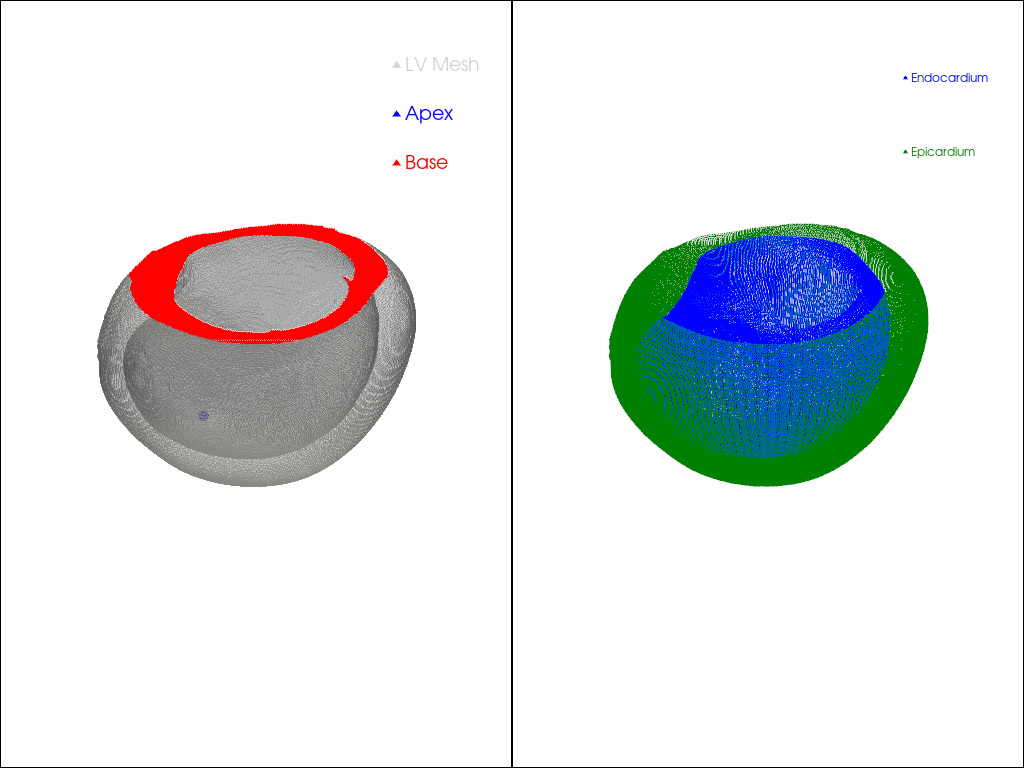

In [60]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave as fw
from scipy import ndimage


sim_grid = fw.PyVistaMeshGrid.from_mesh(sim_mesh, as_surface=True)

pv.set_jupyter_backend("static")

pl = pv.Plotter(shape=(1, 2), notebook=True)
pl.subplot(0, 0)
pl.add_mesh(sim_grid, color="lightgray", opacity=0.3, label="LV Mesh")
pl.add_points(apex_coords * 1., color="blue", point_size=1, label="Apex")
pl.add_points(base_coords * 1., color="red", point_size=1, label="Base")
pl.add_legend()

pl.subplot(0, 1)
pl.add_points(endo_coords * 1., color="blue", point_size=1, label="Endocardium")
pl.add_points(epi_coords * 1., color="green", point_size=1, label="Epicardium")
pl.add_legend()
pl.show()

In [61]:
tissue = fw.CardiacTissue(full_mesh.shape, dr=.2)
tissue.mesh = full_mesh.astype(np.uint8)

diffusion_model = fw.DiffusionModel()
diffusion_model.stencil = fw.IsotropicStencil()
K, M = diffusion_model.compute_weights(tissue)

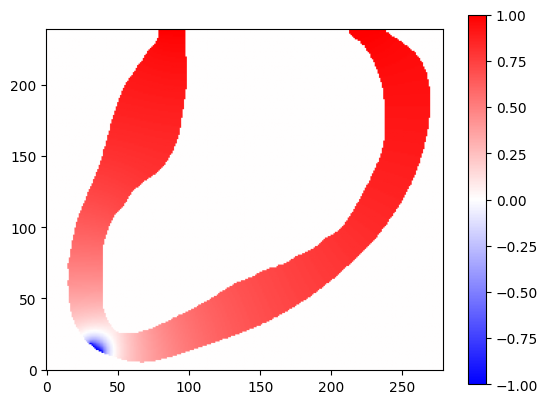

In [ ]:
from finitewave_tools.solvers.poisson_solver import LaplaceSolver

solver = LaplaceSolver()
apex_base_vals = solver.solve(K, apex_base_boundaries)

apex_base_mesh = np.zeros_like(full_mesh, dtype=np.float64)
apex_base_mesh[full_mesh > 0] = apex_base_vals.astype(np.float64)

plt.figure()
plt.imshow(apex_base_mesh[apex_center[0]].T, cmap="bwr", origin="lower")
plt.colorbar()
plt.show()

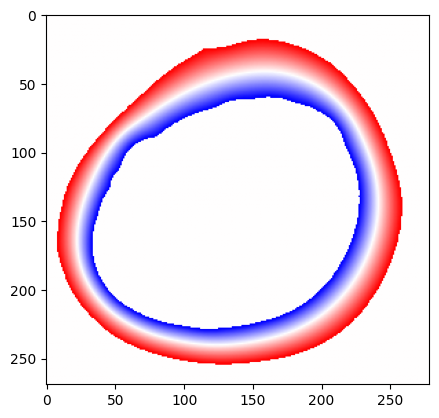

In [63]:
endo_epi_laplace = solver.solve(K, endo_epi_boundaries)
endo_epi_mesh = np.zeros_like(full_mesh, dtype=np.float64)

endo_epi_mesh[full_mesh > 0] = endo_epi_laplace.astype(np.float64)

plt.figure()
plt.imshow(endo_epi_mesh[:, :, endo_epi_mesh.shape[2]//2], cmap="bwr")
plt.show()

In [7]:
def compute_gradient(mesh):
    dx, dy, dz = np.gradient(mesh, axis=(0, 1, 2), edge_order=2)
    return np.array([dx, dy, dz])


def normalize_vectors(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    if np.any(norms == 0):
        raise ValueError("Zero-length vector found; cannot normalize.")
    return vectors / norms


apex_base_grad = compute_gradient(apex_base_mesh)
endo_epi_grad = compute_gradient(endo_epi_mesh)

long_grad = np.array([v[sim_mesh > 0] for v in apex_base_grad]).T
long_grad = normalize_vectors(long_grad)
trans_grad = np.array([v[sim_mesh > 0] for v in endo_epi_grad]).T
trans_grad = normalize_vectors(trans_grad)

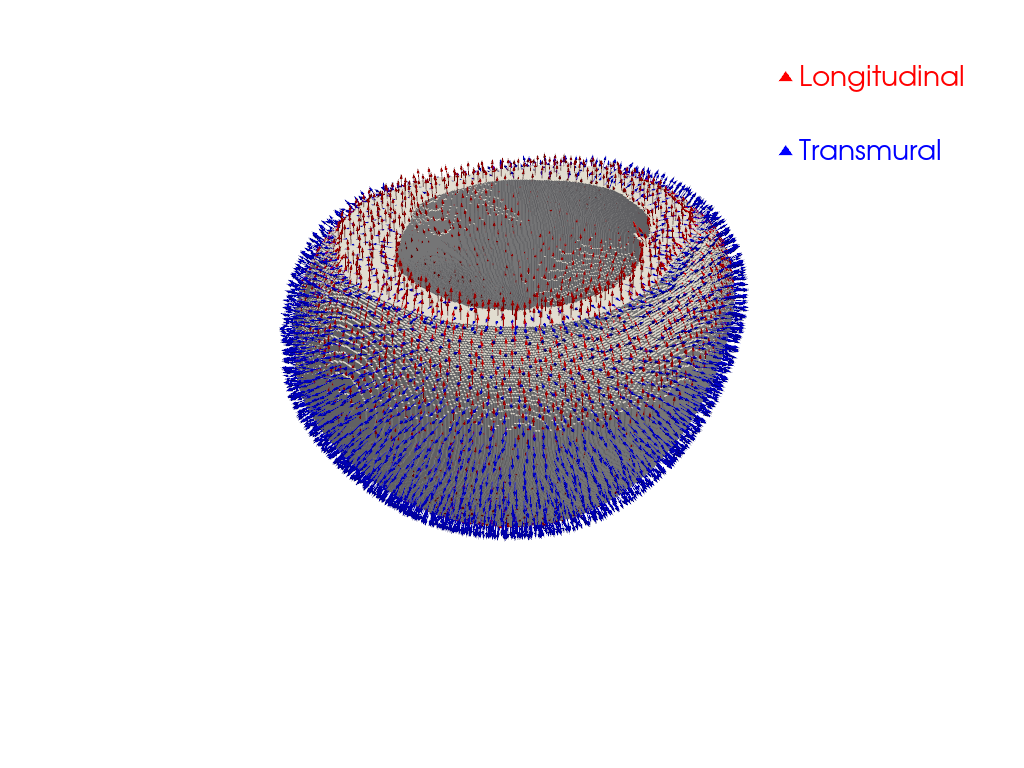

In [16]:
from finitewave_tools.meshkit.points.point_sampler import select_random_points


nonzero_inds = np.unique(sim_grid["nonzero_inds"])
surface_coords = np.argwhere(sim_mesh > 0)[nonzero_inds]

selected_point_ids = select_random_points(surface_coords, distance=5)
selected_coords = surface_coords[selected_point_ids]

nonzero_selected_ids = nonzero_inds[selected_point_ids]

apex_base_vec = long_grad[nonzero_selected_ids]
endo_epi_vec = trans_grad[nonzero_selected_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(sim_grid, color="white", opacity=1)
pl.add_arrows(selected_coords, apex_base_vec, mag=10, color="red", label="Longitudinal")
pl.add_arrows(selected_coords, endo_epi_vec, mag=10, color="blue", label="Transmural")
pl.add_legend()
pl.show()


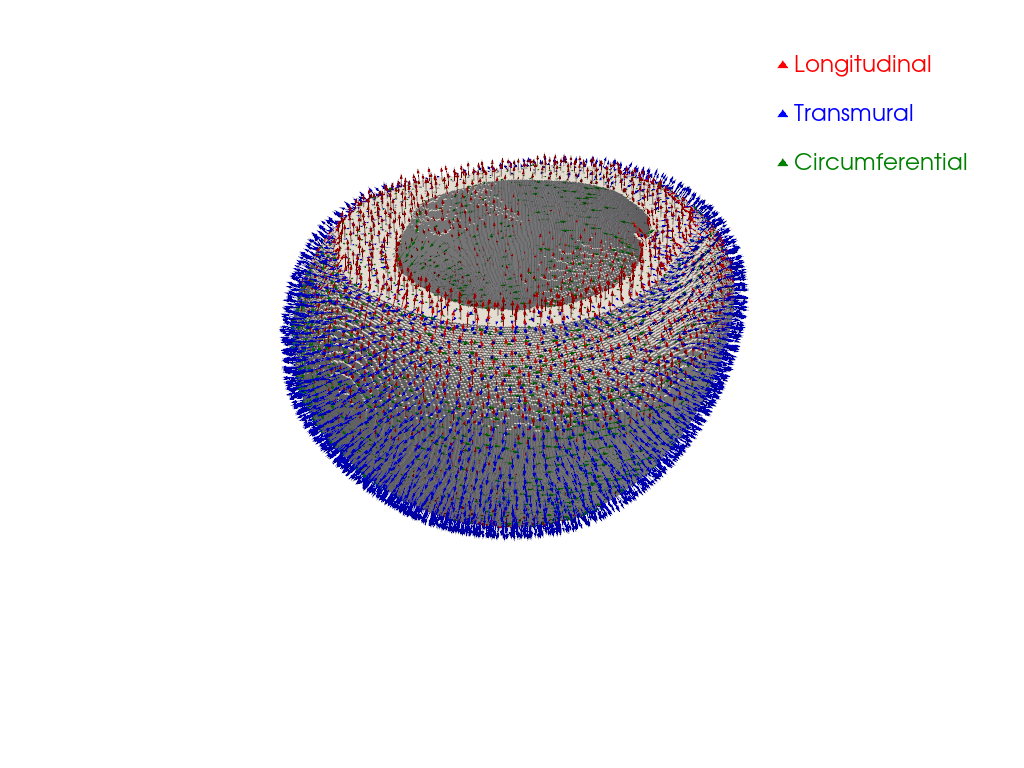

In [17]:
def correct_transmural_direction(el, et):
    et_corr = et - np.sum(et * el, axis=1, keepdims=True) * el
    et_corr = normalize_vectors(et_corr)
    return et_corr


el = long_grad
et = correct_transmural_direction(el, trans_grad)
ec = normalize_vectors(np.cross(el, et))

el_selected = el[nonzero_selected_ids]
et_selected = et[nonzero_selected_ids]
ec_selected = ec[nonzero_selected_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(sim_grid, color="white", opacity=1.)
pl.add_arrows(selected_coords, el_selected, mag=10, color="red", label="Longitudinal")
pl.add_arrows(selected_coords, et_selected, mag=10, color="blue", label="Transmural")
pl.add_arrows(selected_coords, ec_selected, mag=10, color="green", label="Circumferential")
pl.add_legend()
pl.show()

## Generate Fibers

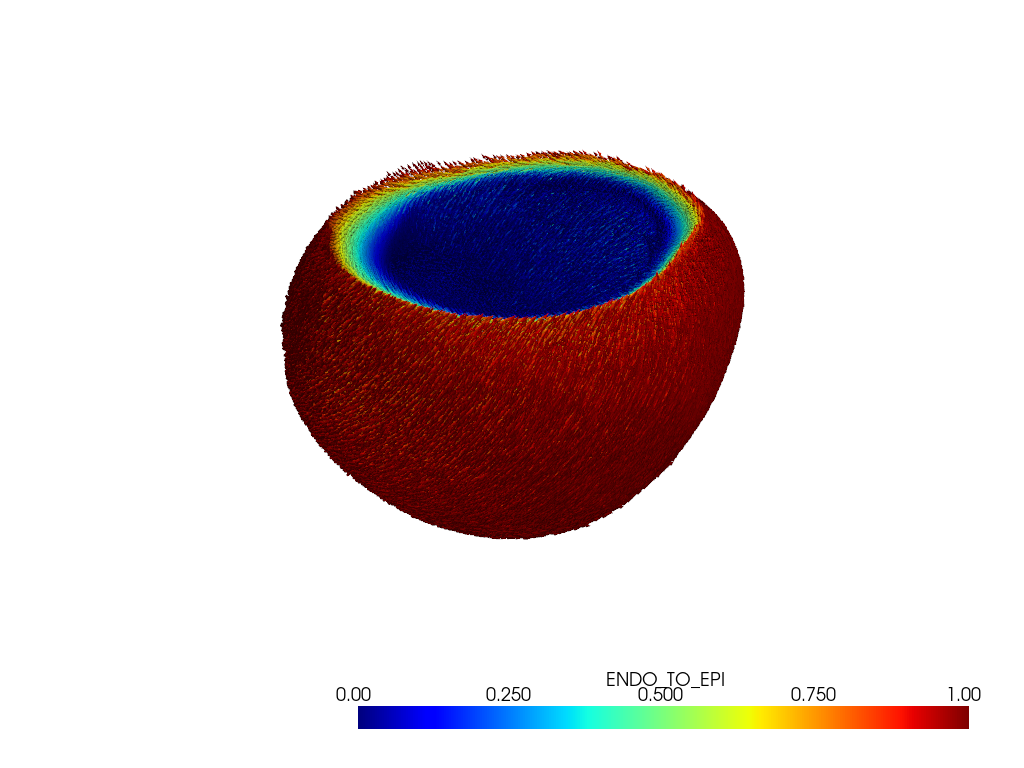

In [25]:
def generate_rule_based_fibers(el, et, ec, alpha, beta):
    fibers = (np.cos(alpha[:, None]) * np.cos(beta[:, None]) * ec +
              np.sin(alpha[:, None]) * np.cos(beta[:, None]) * el +
              np.sin(beta[:, None]) * et)
    return fibers


def compute_fiber_angles(endo_epi_dist, alpha_endo=-60, alpha_epi=60):
    alpha = endo_epi_dist * (alpha_epi - alpha_endo) + alpha_endo
    return alpha


def sample_from_layers(distance, coords, n_layers, radius):
    layer_values = np.linspace(0, 1, n_layers + 1)
    result_indices = []
    original_indices = np.arange(coords.shape[0])
    for i in range(n_layers):
        layer_mask = (distance >= layer_values[i]) & (distance < layer_values[i + 1])
        layer_coords = coords[layer_mask]
        if layer_coords.size > 0:
            sampled_indices = select_random_points(layer_coords, distance=radius)
            result_indices.append(original_indices[layer_mask][sampled_indices])
    sampled_indices = np.concatenate(result_indices)
    return sampled_indices


def build_arrows(coords, vectors, colors, scale_factor=5):
    mesh = pv.PolyData(coords * 1.)
    mesh.point_data["Fibers"] = vectors
    mesh.point_data["ENDO_TO_EPI"] = colors

    arrows = mesh.glyph(
        orient="Fibers", 
        scale=False,  
        factor=scale_factor
    )
    return arrows


endo_epi_dist = (endo_epi_mesh[sim_mesh > 0] + 1) / 2

alpha = compute_fiber_angles(endo_epi_dist, alpha_endo=-np.pi/3, alpha_epi=np.pi/3)
beta = np.zeros_like(alpha)

fibers = generate_rule_based_fibers(el, et, ec, alpha, beta)
coords = np.argwhere(sim_mesh > 0)

selected_layer_ids = sample_from_layers(endo_epi_dist, coords, n_layers=5, radius=2)
selected_coords = coords[selected_layer_ids]
fibers_selected = fibers[selected_layer_ids]
distance_selected = endo_epi_dist[selected_layer_ids]

arrow_poly = build_arrows(selected_coords, fibers_selected, distance_selected, scale_factor=10)

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(arrow_poly, scalars="ENDO_TO_EPI", cmap="jet", label="Fibers",
            clim=[0, 1])
pl.show()

In [43]:
np.linspace(0, 1, 6)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

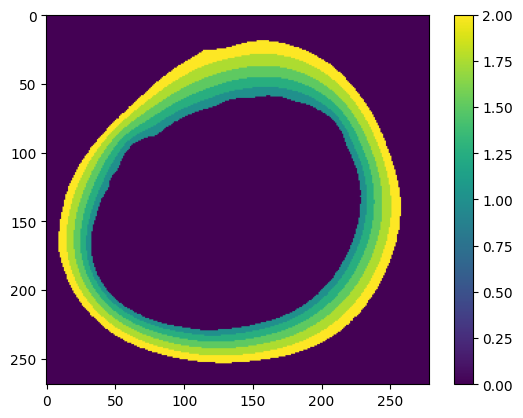

In [42]:
layers = (np.digitize(endo_epi_dist, bins=np.linspace(0, 1, 6)) - 1) / 4
layers_mesh = np.zeros_like(sim_mesh, dtype=np.float64)
layers_mesh[sim_mesh > 0] = 1 + layers.astype(np.float64)

plt.figure()
plt.imshow(layers_mesh[:, :, layers_mesh.shape[2]//2], cmap="viridis")
plt.colorbar()
plt.show()

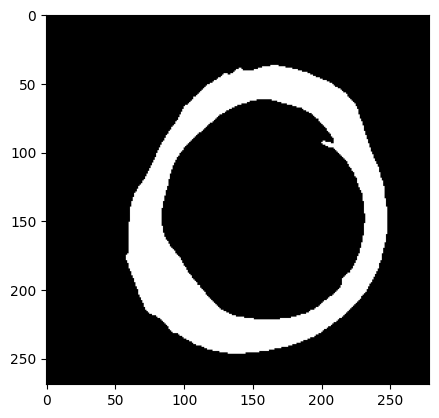

In [52]:
m = sim_mesh.copy()

axis = 2
z_max = np.argwhere(m > 0)[:, axis].max()

res_before = m.take(indices=[z_max], axis=axis).squeeze()
idx = [slice(None)] * m.ndim
idx[axis] = z_max
m[tuple(idx)] = False

res = m.take(indices=[z_max], axis=axis).squeeze()

plt.imshow(res_before, cmap="gray")
plt.show()